In [27]:
from src.mesh import Mesh3D
import numpy as np
from skimage.measure import marching_cubes
import pyvista as pv
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [28]:
euler_cube = np.load('./output/euler_cube.npy')
coord_cube = np.load('./output/coord_cube.npy')
Nb_cube = np.load('./output/Nb_cube.npy')
Sn_cube = np.load('./output/Sn_cube.npy')
points = np.load('./output/points.npy')
euler_flat = np.load('./output/euler_flat.npy')
Sn_flat = np.load('./output/Sn_flat.npy')
Nb_flat = np.load('./output/Nb_flat.npy')
Sn_points = np.copy(points)
phase_flat = np.load('./output/phase_flat.npy')


In [29]:
"""Find the vacuum interface"""


total_xray_cube = Nb_cube + Sn_cube
total_xray_cube = np.pad(total_xray_cube, pad_width=10, mode='edge')
Nb_cube = np.pad(Nb_cube, pad_width=10, mode='edge')

verts, faces, normals, values = marching_cubes(total_xray_cube,120000,spacing=(0.1,0.1,0.1))
verts = verts - np.array((1.0,1.0,1.0))
surface_mesh = pv.PolyData.from_regular_faces(verts, faces).subdivide(1).smooth(n_iter=10, relaxation_factor=0.1, boundary_smoothing=False).compute_normals(auto_orient_normals=True).triangulate()

verts, faces, normals, values = marching_cubes(Nb_cube,165000,spacing=(0.1,0.1,0.1))
verts = verts - np.array((1.0,1.0,1.0))
substrate_mesh = pv.PolyData.from_regular_faces(verts, faces).smooth(n_iter=20, relaxation_factor=0.1, boundary_smoothing=False).compute_normals(auto_orient_normals=True).triangulate()

"""Find points in vacuum"""
points_pv = pv.PolyData(points)
outside_points = points_pv.select_enclosed_points(surface_mesh.extrude([-10.0,0.0,0.0], capping=True), inside_out=True)
outside_mask = outside_points['SelectedPoints'].view(np.bool_)

phase_flat[outside_mask] = 3    # 3 -> Vacuum

point_data = {
    "euler": euler_flat,
    "phase": phase_flat
}

bounds = np.array(((0.0, 0.1*coord_cube.shape[0]),
        (0.0, 0.1*coord_cube.shape[1]),
        (0.0, 0.1*coord_cube.shape[2])))

mesh = Mesh3D(points, point_data, bounds)

/home/vike/dev/3debsd/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_array is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


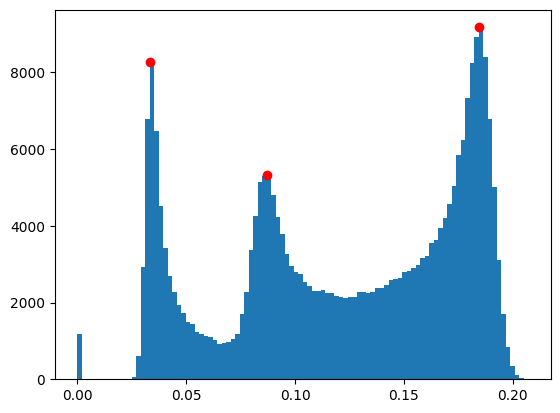

In [35]:
counts, bin_edges, patches = plt.hist(Sn_flat / (Nb_flat + Sn_flat + 1), bins=100)
peaks, _ = find_peaks(counts, height=4000)
plt.scatter(bin_edges[peaks], counts[peaks], c="red")
lower_Sn_peak, _, upper_Sn_peak = bin_edges[peaks]

In [36]:


bbox = bounds

points = Sn_points
scalars = 0.25 * (Sn_flat / (Nb_flat + Sn_flat + 1) - lower_Sn_peak) / (upper_Sn_peak - lower_Sn_peak)

plane_x = 2.7
grid_y, grid_z = np.meshgrid(np.linspace(bbox[1][0]-0.1, bbox[1][1]+0.1, 100), np.linspace(bbox[2][0]-0.1, bbox[2][1]+0.1, 100))
grid_x = np.full_like(grid_y, plane_x)
grid_points = np.c_[grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]

interpolated_scalars = griddata(points, scalars, grid_points, method='linear')

structured_grid = pv.StructuredGrid()
structured_grid.points = np.c_[grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]
structured_grid.dimensions = grid_x.shape + (1,)
structured_grid["interpolated_scalar"] = interpolated_scalars


In [37]:
import pyvista as pv
pv.set_jupyter_backend('client')
pv.global_theme.allow_empty_mesh = True

plotter = pv.Plotter(off_screen=True, window_size=(1920, 1080))

grains = mesh.grains
grain_phase = mesh.grain_phase

colors = np.random.rand(len(grains),3)
plane_color = pv.Color(opacity=0.5)

plotter.add_mesh(structured_grid.rotate_y(-90).rotate_z(180).translate([0.1,0.1+bounds[1][1],0.1]), scalars="interpolated_scalar", cmap="viridis", show_edges=False, opacity=1.0)
for id in range(len(grains)):

    if (grain_phase[id] == 3).any():
        continue
    # if (grain_phase[id] == 1).any():
    #     continue
    if len(grains[id]) > 10:
        grain_mesh = mesh.plot_grain(id)
        plotter.add_mesh(grain_mesh.intersection(structured_grid.extract_surface().triangulate(), split_first=False, split_second=False)[0].rotate_y(-90).rotate_z(180).translate([0.1,0.1+bounds[1][1],0.1]), line_width=4)
        plotter.add_mesh(grain_mesh.clip_surface(structured_grid).rotate_y(-90).rotate_z(180).translate([0.1,0.1+bounds[1][1],0.1]), color=colors[id])
        plotter.add_mesh(grain_mesh.clip_surface(structured_grid, invert=False).rotate_y(-90).rotate_z(180).translate([0.1,0.1+bounds[1][1],0.1]), color=colors[id],opacity=0.1)

plotter.scalar_bar.title = "Sn Concentration"
plotter.scalar_bar.vertical_title_separation = 50
plotter.scalar_bar.unconstrained_font_size = 20
plotter.scalar_bar.orientation = True
plotter.scalar_bar.position = (0.85,0.1)
plotter.scalar_bar.height = 0.5
plotter.scalar_bar.width = 0.1

plotter.save_graphic("./example.svg")


2025-11-20 16:02:56.825 (7712.479s) [    7C6516006100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-20 16:02:57.886 (7713.540s) [    7C6516006100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-20 16:02:59.704 (7715.358s) [    7C6516006100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-20 16:03:00.096 (7715.750s) [    7C6516006100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-20 16:03:00.270 (7715.925s) [    7C6516006100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-20 16:03:00.989 (7716.644s) [    7C6516006100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-20 16:03:01.447 (7717.102s) [    7C6516006100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-20 16:03:02.005 (7717.660s) [    7C6516006100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-20 16:03